# Imports and data/model preparation

In [14]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.ViT import ViTClassifier_base
import torch
import torch.nn as nn
import torchmetrics.classification as metrics
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

## Visualize study parameters

In [15]:
study_file = PROJ_ROOT / 'studies/ViTClassifier_base_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [16]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.350233,2025-08-06 19:46:33.879878,2025-08-06 20:19:39.970606,0 days 00:33:06.090728,0.000135,128,0.3,0.000004,512,2048.0,2,0.001272,0.348987,0.349453,COMPLETE
1,1,0.070144,2025-08-06 20:19:40.403181,2025-08-06 20:53:23.763263,0 days 00:33:43.360082,0.000001,128,0.0,0.002205,256,NaN,1,0.001286,0.063092,0.066188,COMPLETE
2,2,0.441123,2025-08-06 20:53:24.438768,2025-08-06 21:26:30.939132,0 days 00:33:06.500364,0.000004,128,0.2,0.000705,2048,128.0,2,0.000051,0.441123,NaN,COMPLETE
9,9,0.062947,2025-08-06 22:44:17.031789,2025-08-06 23:18:23.605944,0 days 00:34:06.574155,0.000007,64,0.0,0.000041,256,NaN,1,0.002551,0.062908,NaN,COMPLETE
13,13,0.065769,2025-08-07 00:00:38.325799,2025-08-07 00:43:05.270858,0 days 00:42:26.945059,0.000001,8,0.0,0.000004,256,NaN,1,0.001063,0.051883,0.063775,COMPLETE
14,14,0.069531,2025-08-07 00:43:08.023000,2025-08-07 01:25:29.271419,0 days 00:42:21.248419,0.000001,8,0.0,0.000003,256,NaN,1,0.000613,0.050628,0.061984,COMPLETE
16,16,0.075850,2025-08-07 01:32:31.305064,2025-08-07 02:10:23.260686,0 days 00:37:51.955622,0.000006,16,0.0,0.000065,256,NaN,1,0.050068,0.064482,NaN,COMPLETE
18,18,0.065489,2025-08-07 02:28:18.517591,2025-08-07 03:06:18.336202,0 days 00:37:59.818611,0.000002,16,0.0,0.000015,512,1024.0,2,0.000250,0.064448,NaN,COMPLETE


In [17]:
params = study.best_params
print(params)

{'backbone_LR': 7.446390798440358e-06, 'head_LR': 4.065521700020252e-05, 'weight_decay': 0.002550813726764217, 'batch_size': 64, 'head_layer_1': 256, 'num_layers': 1, 'dropout': 0.0}


In [18]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [19]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [20]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='classification', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='classification', )
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='classification', )

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8)

In [21]:
head_cfg = {
    'hidden_dims' : [256],
    'dropout_rate': params['dropout']
}
model = ViTClassifier_base(img_size=224, head_cfg=head_cfg)

loss = torch.nn.CrossEntropyLoss()
ES = EarlyStopping(patience=4, restore_best_weights=True)
met = {
    "accuracy": metrics.BinaryAccuracy(),
    "precision": metrics.BinaryPrecision(),
    "recall": metrics.BinaryRecall(),
}

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 20

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss, met)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Compute CV loss

In [22]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="classification", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/181 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/181 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]

...


Epoch 14/15:   0%|          | 0/181 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]


Epoch 15/15:   0%|          | 0/181 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/46 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.1179
5-fold CV loss: 0.1286
k-Fold CV loss: 0.12858


## Train classifier

In [39]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'classification', epochs=EPOCHS, early_stopping=ES)


Epoch 1/20:   0%|          | 0/226 [00:00<?, ?it/s]

[1/20] Train Loss: 0.2432


Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9506
	precision: 0.9486
	recall: 0.9529
[1/20] Val Loss: 0.1544 



Epoch 2/20:   0%|          | 0/226 [00:00<?, ?it/s]

...

	accuracy: 0.9339
	precision: 0.9334
	recall: 0.9345
[8/20] Val Loss: 0.1850 



Epoch 9/20:   0%|          | 0/226 [00:00<?, ?it/s]

[9/20] Train Loss: 0.1150


Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9337
	precision: 0.9339
	recall: 0.9336
[9/20] Val Loss: 0.1794 
Stopping training due to EarlyStopping


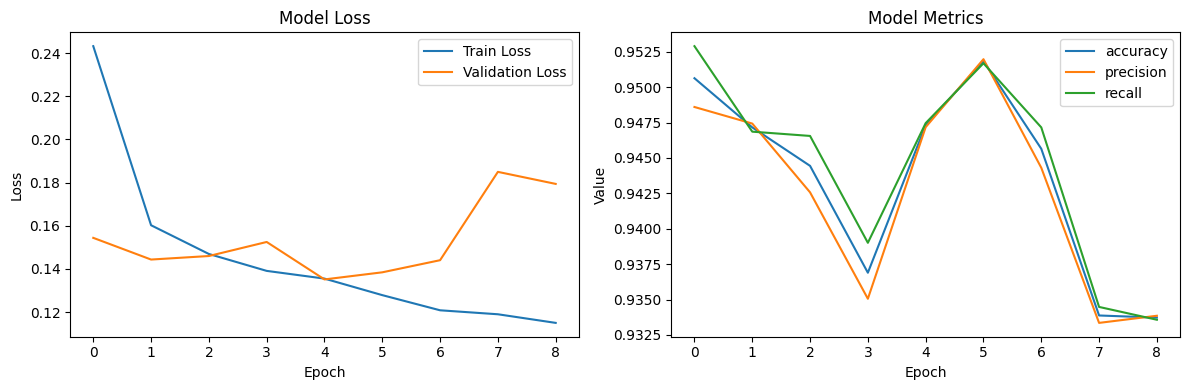

In [40]:
plot_history(trainer.history)

#### Validation Results

In [41]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR)

Evaluation:   0%|          | 0/52 [00:00<?, ?it/s]

	accuracy: 0.9473
	precision: 0.9472
	recall: 0.9475
Model ViTClassifier_base_classification.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [42]:
y_hat, y_true, test_loss = trainer.predict(test_loader)
print(f'Test Loss: {test_loss}')

Evaluation:   0%|          | 0/48 [00:00<?, ?it/s]

Test Loss: 0.2339057360610847


In [43]:
import torch.nn as nn
y_hat_np = nn.Softmax()(y_hat)[:,0].numpy()
y_true_np = y_true[:,0].numpy()

/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1751: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



In [44]:
def print_metrics(y_hat: np.ndarray, y_true: np.ndarray):
    print(classification_report(y_true, y_hat))
    print(f'Accuracy: {accuracy_score(y_true, y_hat)}')
    print(f'Precision: {precision_score(y_true, y_hat)}')
    print(f'Recall: {recall_score(y_true, y_hat)}')

    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_hat)
    #print cm values with labels
    cm_df = pd.DataFrame(cm, index=['Not Explored', 'Explored'], columns=['Not Explored', 'Explored'])
    print("Confusion Matrix DataFrame:")
    print(cm_df)

### Classification metrics for $\theta = 0.5$

In [45]:
y_hat_theta = (y_hat_np > 0.5).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88      1377
         1.0       0.94      0.84      0.89      1632

    accuracy                           0.88      3009
   macro avg       0.88      0.89      0.88      3009
weighted avg       0.89      0.88      0.88      3009

Accuracy: 0.8830176138251911
Precision: 0.9395604395604396
Recall: 0.8382352941176471
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1289        88
Explored               264      1368


### Classification metrics for $\theta = 0.8$

In [46]:
y_hat_theta = (y_hat_np > 0.8).astype(float)
print_metrics(y_hat_theta, y_true_np)

              precision    recall  f1-score   support

         0.0       0.79      0.97      0.87      1377
         1.0       0.97      0.78      0.86      1632

    accuracy                           0.87      3009
   macro avg       0.88      0.87      0.87      3009
weighted avg       0.89      0.87      0.87      3009

Accuracy: 0.8660684612828182
Precision: 0.9687261632341724
Recall: 0.7781862745098039
Confusion Matrix DataFrame:
              Not Explored  Explored
Not Explored          1336        41
Explored               362      1270


### Visualize ROC & AUROC

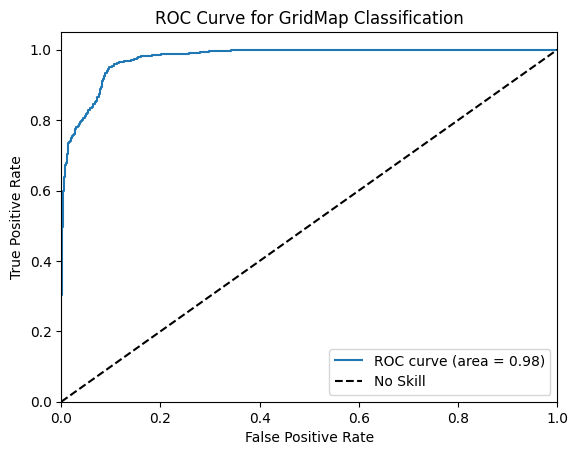

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true_np, y_hat_np)
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for GridMap Classification')
plt.legend()
plt.show()